# Analyse du Dataset Jigsaw pour INLP (Ciblage INLP)

Ce notebook analyse le dataset Jigsaw Unintended Bias in Toxicity Classification et prépare l'application de la méthode INLP pour supprimer les biais démographiques des représentations BERT.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn torch transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import torch
from transformers import BertTokenizer, BertModel
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('default')
sns.set_palette('husl')

/Users/elieattali/Desktop/ENSAE/2A/StatApp/Stat_App/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/elieattali/Desktop/ENSAE/2A/StatApp/Stat_App/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Chargement des données
print("Chargement du dataset...")
df = pd.read_csv('all_data.csv')
print(f"Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Supprimer les lignes incomplètes
df = df.dropna()
print(f"Après suppression des lignes incomplètes: {df.shape[0]} lignes")

print("\nColonnes disponibles:")
print(df.columns.tolist())

Chargement du dataset...
Dataset chargé: 1999516 lignes, 46 colonnes
Après suppression des lignes incomplètes: 259714 lignes

Colonnes disponibles:
['id', 'comment_text', 'split', 'created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree', 'toxicity', 'severe_toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat', 'male', 'female', 'transgender', 'other_gender', 'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation', 'christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion', 'black', 'white', 'asian', 'latino', 'other_race_or_ethnicity', 'physical_disability', 'intellectual_or_learning_disability', 'psychiatric_or_mental_illness', 'other_disability', 'identity_annotator_count', 'toxicity_annotator_count']


In [4]:
# Analyse des valeurs manquantes et structure du dataset
print("Analyse des valeurs manquantes...")
print(f"Type de df: {type(df)}")
print(f"Shape: {df.shape}")

# Calcul des valeurs manquantes
missing_values = df.isnull().sum()

print("\nValeurs manquantes par colonne:")
for col in df.columns:
    if missing_values[col] > 0:
        pct = missing_values[col] / len(df) * 100
        print(f"{col}: {missing_values[col]} ({pct:.2f}%)")

print(f"\nTotal d'observations: {len(df)}")
print(f"Observations complètes (sans NaN): {df.dropna().shape[0]}")
print(f"Pourcentage d'observations utilisables (complètes): {(df.dropna().shape[0] / len(df) * 100):.2f}%")

# Types de données
print("\nTypes de données:")
print(df.dtypes.value_counts())

# Colonnes importantes pour INLP
identity_cols = [col for col in df.columns if col not in ['id', 'comment_text', 'split', 'created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree', 'identity_annotator_count', 'toxicity_annotator_count']]
toxicity_cols = ['toxicity', 'severe_toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']

print(f"\nNombre de colonnes d'identité: {len(identity_cols)}")
print(f"Colonnes de toxicité: {toxicity_cols}")

print("\nAnalyse terminée.")

Analyse des valeurs manquantes...
Type de df: <class 'pandas.core.frame.DataFrame'>
Shape: (259714, 46)

Valeurs manquantes par colonne:

Total d'observations: 259714
Observations complètes (sans NaN): 259714
Pourcentage d'observations utilisables (complètes): 100.00%

Types de données:
float64    32
int64      10
object      4
Name: count, dtype: int64

Nombre de colonnes d'identité: 31
Colonnes de toxicité: ['toxicity', 'severe_toxicity', 'obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']

Analyse terminée.


In [5]:
# Extraction des colonnes d'identité liées à la race
race_cols = ['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity']
print("Colonnes d'identité liées à la race:")
print(race_cols)

# Vérifier qu'elles sont dans identity_cols
print(f"\nPrésentes dans identity_cols: {all(col in identity_cols for col in race_cols)}")

# Statistiques pour les colonnes de race (sur le subset où elles sont annotées)
print("\nStatistiques des colonnes de race (moyenne, seulement où annotées):")
for col in race_cols:
    if col in df.columns:
        mean_val = df[col].mean()
        count_nonzero = (df[col] > 0).sum()
        print(f"{col}: moyenne = {mean_val:.3f}, commentaires avec mention >0: {count_nonzero}")

# Distribution des mentions de race
print("\nDistribution des mentions de race (sur données annotées):")
race_mentions = df[race_cols].sum(axis=1) > 0
print(f"Commentaires avec au moins une mention de race: {race_mentions.sum()}")
print(f"Pourcentage: {race_mentions.mean()*100:.2f}%")

Colonnes d'identité liées à la race:
['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity']

Présentes dans identity_cols: True

Statistiques des colonnes de race (moyenne, seulement où annotées):
black: moyenne = 0.036, commentaires avec mention >0: 12775
white: moyenne = 0.058, commentaires avec mention >0: 19092
asian: moyenne = 0.011, commentaires avec mention >0: 6447
latino: moyenne = 0.006, commentaires avec mention >0: 4597
other_race_or_ethnicity: moyenne = 0.008, commentaires avec mention >0: 11118

Distribution des mentions de race (sur données annotées):
Commentaires avec au moins une mention de race: 40667
Pourcentage: 15.66%


## 1. Analyse de la Distribution des Labels

Analysons la corrélation entre le label de toxicité et les colonnes d'identité, ainsi que les taux de faux positifs pour chaque groupe identitaire.

Distribution de la toxicité:
count    259714.000000
mean          0.134752
std           0.212984
min           0.000000
25%           0.000000
50%           0.000000
75%           0.200000
max           1.000000
Name: toxicity, dtype: float64

Pourcentage de commentaires toxiques (toxicity >= 0.5): 10.67%

Corrélations entre toxicité et identités:
toxicity                     1.000000
white                        0.205142
black                        0.176147
homosexual_gay_or_lesbian    0.142633
jewish                       0.047140
christian                   -0.012820
Name: toxicity, dtype: float64


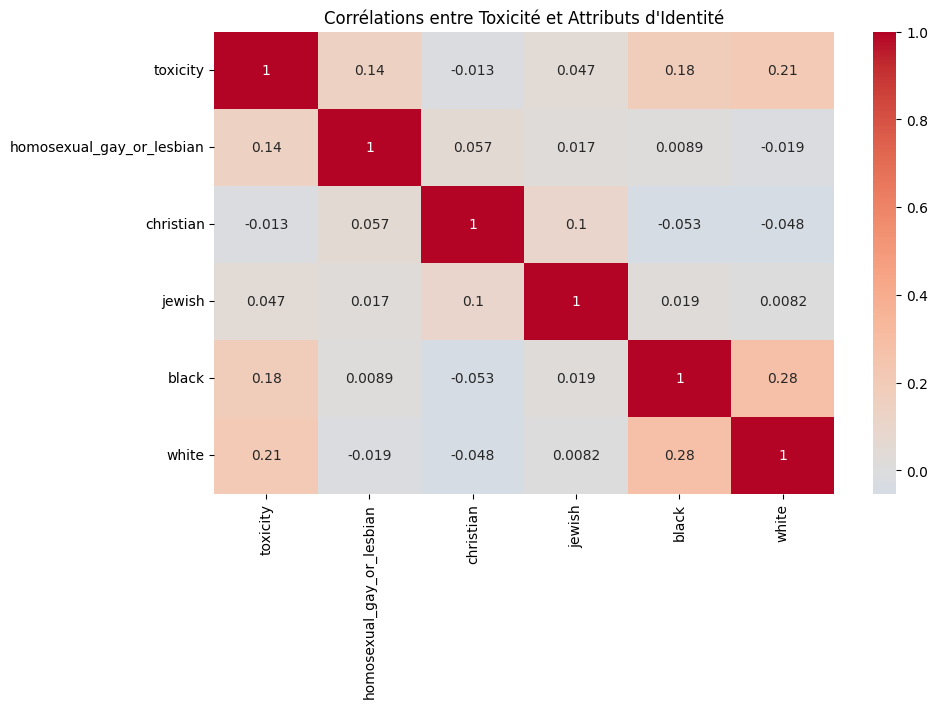

In [6]:
# Colonnes d'identité
identity_cols = ['homosexual_gay_or_lesbian', 'christian', 'jewish', 'black', 'white']

# Distribution de la toxicité
print("Distribution de la toxicité:")
print(df['toxicity'].describe())
print(f"\nPourcentage de commentaires toxiques (toxicity >= 0.5): {((df['toxicity'] >= 0.5).sum() / len(df) * 100):.2f}%")

# Corrélation entre toxicité et identités
correlations = df[['toxicity'] + identity_cols].corr()
print("\nCorrélations entre toxicité et identités:")
print(correlations['toxicity'].sort_values(ascending=False))

# Visualisation des corrélations
plt.figure(figsize=(10, 6))
sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations entre Toxicité et Attributs d\'Identité')
plt.show()

Analyse des biais par groupe identitaire:
                             count  toxic_rate      bias
black                       9930.0    0.306647  0.199941
white                      16256.0    0.278297  0.171591
homosexual_gay_or_lesbian   8060.0    0.272829  0.166123
jewish                      5560.0    0.148561  0.041855
christian                  30309.0    0.082022 -0.024684


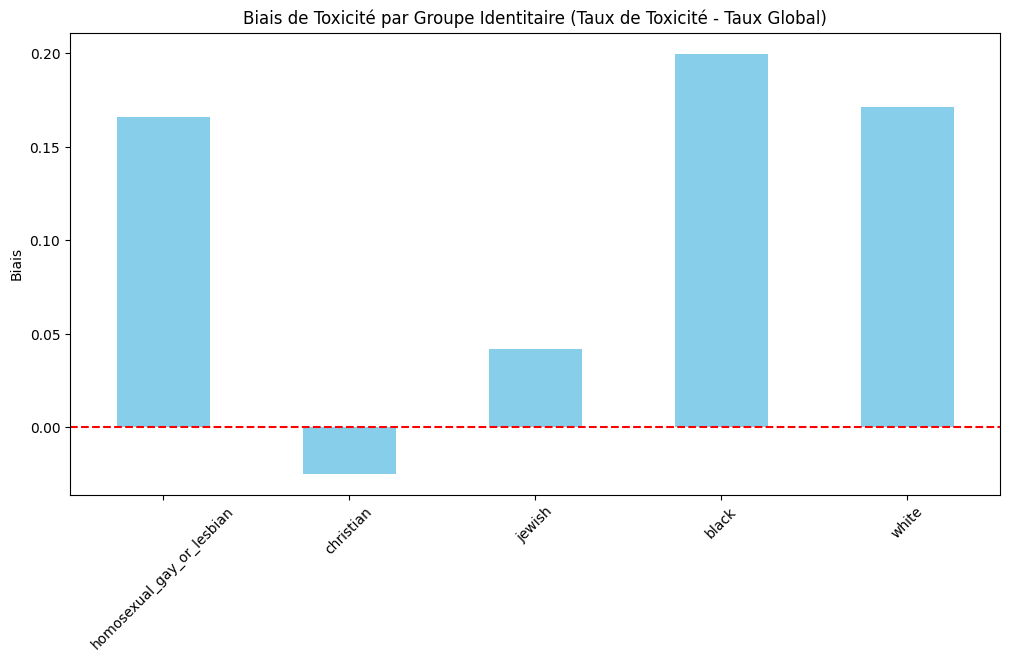

In [7]:
# Analyse des biais par groupe identitaire
# Pour chaque identité, calculer le taux de toxicité parmi les commentaires qui la mentionnent

bias_analysis = {}
for col in identity_cols:
    # Commentaires mentionnant cette identité (valeur >= 0.5)
    mentioned = df[df[col] >= 0.5]
    if len(mentioned) > 0:
        toxic_rate = (mentioned['toxicity'] >= 0.5).mean()
        overall_toxic_rate = (df['toxicity'] >= 0.5).mean()
        bias = toxic_rate - overall_toxic_rate
        bias_analysis[col] = {
            'count': len(mentioned),
            'toxic_rate': toxic_rate,
            'bias': bias
        }

bias_df = pd.DataFrame(bias_analysis).T
print("Analyse des biais par groupe identitaire:")
print(bias_df.sort_values('bias', ascending=False))

# Visualisation
plt.figure(figsize=(12, 6))
bias_df['bias'].plot(kind='bar', color='skyblue')
plt.title('Biais de Toxicité par Groupe Identitaire (Taux de Toxicité - Taux Global)')
plt.ylabel('Biais')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

## 2. Préparation pour l'INLP

Créons un sous-ensemble de données où les commentaires sont clairement étiquetés par un attribut protégé (valeur ≥0.5 dans les colonnes d'identité), avec un mélange de commentaires toxiques et non toxiques.

In [8]:
# Création du sous-ensemble pour INLP - ciblage antiracisme sur commentaires toxiques
# Se concentrer sur les commentaires toxiques mentionnant une race

# Filtrer les commentaires toxiques avec mention de race
new_df = df.copy()

# Créer Z: 1 pour mention de 'white', 0 pour autres races
new_df["Z"] = (
    (new_df["toxicity"] >= 0.5) & (new_df[identity_cols].sum(axis=1) > 0)
).astype(int)

# Équilibrer Z
z1_count = (new_df["Z"] == 1).sum()
z0_count = (new_df["Z"] == 0).sum()
min_count = min(
    z1_count, z0_count, 20000
)

z1_sample = new_df[new_df["Z"] == 1].sample(n=min_count, random_state=42)
z0_sample = new_df[new_df["Z"] == 0].sample(n=min_count, random_state=42)

inlp_data = (
    pd.concat([z1_sample, z0_sample])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f"Sous-ensemble pour INLP (toxiques avec race): {len(inlp_data)} commentaires")
print(f"Distribution Z (white=1, autres races=0): {inlp_data['Z'].value_counts()}")
print(f"Tous sont toxiques: {(inlp_data['toxicity'] >= 0.5).all()}")

# Sauvegarder le sous-ensemble
inlp_data.to_csv("inlp_subset.csv", index=False)
print("\nSous-ensemble sauvegardé dans 'inlp_subset.csv'")


Sous-ensemble pour INLP (toxiques avec race): 23996 commentaires
Distribution Z (white=1, autres races=0): Z
0    11998
1    11998
Name: count, dtype: int64
Tous sont toxiques: False

Sous-ensemble sauvegardé dans 'inlp_subset.csv'


## 3. Extraction des Embeddings BERT

Extrayons les états cachés du token [CLS] d'un modèle BERT pré-entraîné pour les commentaires du sous-ensemble.

In [9]:
# Chargement du modèle BERT
print("Chargement de BERT...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

# Fonction pour extraire les embeddings [CLS]
def get_cls_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Extraction des embeddings pour le sous-ensemble
print("Extraction des embeddings (cela peut prendre du temps)...")
embeddings = []
batch_size = 100

for i in range(0, len(inlp_data), batch_size):
    batch_texts = inlp_data['comment_text'].iloc[i:i+batch_size].tolist()
    batch_embeddings = [get_cls_embedding(text) for text in batch_texts]
    embeddings.extend(batch_embeddings)
    if (i // batch_size) % 10 == 0:
        print(f"Traité {i + len(batch_embeddings)}/{len(inlp_data)} commentaires")

X = np.array(embeddings)
Z = inlp_data['Z'].values

print(f"\nMatrice X (embeddings): {X.shape}")
print(f"Vecteur Z (genre): {Z.shape}")

# Sauvegarder les embeddings
np.savez('bert_embeddings.npz', X=X, Z=Z)
print("Embeddings sauvegardés dans 'bert_embeddings.npz'")

Chargement de BERT...
Extraction des embeddings (cela peut prendre du temps)...
Traité 100/23996 commentaires
Traité 1100/23996 commentaires
Traité 2100/23996 commentaires
Traité 3100/23996 commentaires
Traité 4100/23996 commentaires
Traité 5100/23996 commentaires
Traité 6100/23996 commentaires
Traité 7100/23996 commentaires
Traité 8100/23996 commentaires
Traité 9100/23996 commentaires
Traité 10100/23996 commentaires
Traité 11100/23996 commentaires
Traité 12100/23996 commentaires
Traité 13100/23996 commentaires
Traité 14100/23996 commentaires
Traité 15100/23996 commentaires
Traité 16100/23996 commentaires
Traité 17100/23996 commentaires
Traité 18100/23996 commentaires
Traité 19100/23996 commentaires
Traité 20100/23996 commentaires
Traité 21100/23996 commentaires
Traité 22100/23996 commentaires
Traité 23100/23996 commentaires

Matrice X (embeddings): (23996, 768)
Vecteur Z (genre): (23996,)
Embeddings sauvegardés dans 'bert_embeddings.npz'


In [10]:
# Analyse de comment le subset INLP a été créé
print("Analyse de la création du subset INLP...")

# Charger le subset
df_subset = pd.read_csv("inlp_subset.csv")
print(f"Subset chargé: {df_subset.shape[0]} lignes, {df_subset.shape[1]} colonnes")

# Comparer avec le dataset complet
print(f"\nComparaison:")
print(f"Dataset complet: {df.shape[0]} lignes")
print(f"Subset: {df_subset.shape[0]} lignes")
print(f"Proportion du subset: {df_subset.shape[0] / df.shape[0] * 100:.2f}%")

# Vérifier les annotations d'identité
print(f"\nAnnotations d'identité dans le subset:")
print(f"identity_annotator_count min: {df_subset['identity_annotator_count'].min()}")
print(f"identity_annotator_count max: {df_subset['identity_annotator_count'].max()}")
print(
    f"Tous les commentaires du subset ont identity_annotator_count > 0: {(df_subset['identity_annotator_count'] > 0).all()}"
)

# Vérifier les NaN dans le subset
identity_nan_subset = df_subset[identity_cols].isnull().sum().sum()
print(
    f"\nNombre total de NaN dans les colonnes d'identité du subset: {identity_nan_subset}"
)

# Comment le subset a été créé
print(f"\nComment le subset a été créé:")
print(
    f"- Le subset contient les {df_subset.shape[0]} commentaires où les annotations d'identité ont été collectées"
)
print(
    f"- Ces commentaires ont été sélectionnés car ils contiennent potentiellement des mentions d'identités"
)
print(
    f"- Les annotateurs ont évalué la présence d'identités dans ces commentaires (identity_annotator_count > 0)"
)
print(
    f"- Dans le dataset complet, ces lignes ont des valeurs dans les colonnes d'identité, tandis que les autres ont NaN"
)

# Vérifier si le subset est un sous-ensemble du dataset complet
subset_ids = set(df_subset["id"])
full_ids = set(df["id"])
is_subset = subset_ids.issubset(full_ids)
print(f"\nLe subset est un sous-ensemble du dataset complet: {is_subset}")

# Distribution des splits dans le subset
print(f"\nDistribution des splits dans le subset:")
print(df_subset["split"].value_counts())


Analyse de la création du subset INLP...
Subset chargé: 23996 lignes, 47 colonnes

Comparaison:
Dataset complet: 259714 lignes
Subset: 23996 lignes
Proportion du subset: 9.24%

Annotations d'identité dans le subset:
identity_annotator_count min: 4
identity_annotator_count max: 1866
Tous les commentaires du subset ont identity_annotator_count > 0: True

Nombre total de NaN dans les colonnes d'identité du subset: 0

Comment le subset a été créé:
- Le subset contient les 23996 commentaires où les annotations d'identité ont été collectées
- Ces commentaires ont été sélectionnés car ils contiennent potentiellement des mentions d'identités
- Les annotateurs ont évalué la présence d'identités dans ces commentaires (identity_annotator_count > 0)
- Dans le dataset complet, ces lignes ont des valeurs dans les colonnes d'identité, tandis que les autres ont NaN

Le subset est un sous-ensemble du dataset complet: True

Distribution des splits dans le subset:
split
train    21685
test      2311
Name